# Identification of a 2-DOF Mass-Spring-Damper System with the RFP Method

***

This notebook demonstrates the identification of a 2-DOF mass-spring-damper system using the Rational Fraction Polynomial (RFP) method, presented for the first time by [Richardson & Formenti (1982)](http://papers.vibetech.com/Paper07.pdf). Unlike the LSCE algorithm explored in our previous notebooks, which works in the time domain by curve fitting the impulse response function (IRF), the RFP method operates in the frequency domain by curve fitting directly the frequency response function (FRF). This approach avoids the issues related to taking the inverse Fourier transform of FRFs that are inevitably limited in their frequency range, which cause a potentially serious error called _time domain leakage_. In fact, looking at the IRFs obtained in [notebook 2](02_Identification_of_a_1-DOF_Mass-Spring-Damper_Sytem_with_the_LSCE_Algorithm.ipynb), it is always possible to notice artificial oscillations at the end of the response, even in the IRF obtained from the Savitzky-Golay-filtered FRF, which produces the best results in terms of modal parameters. By working in the frequency domain, the RFP method is able to avoid this issue and provide a more robust estimation of the system's modal parameters.

To understand the RFP method and its application, we'll follow a structured approach with these key steps:

* [Theoretical Background](#theoretical-background)
    * [Modeling System Dynamics in the Laplace Domain](#modeling-laplace)
    * [Transfer Function and FRF of the 2-DOF System](#transfer-function-frf)
    * [RFP Method](#rfp-method)
    * [Orthogonal Polynomials Implementation](#orthogonal-polynomials)
    * [Global Parameter Estimation](#global-estimation)
* [Parameter Estimation from Random Excitation](#estimation-random)
    * [Data Generation](#data-generation)
    * [Data Processing](#data-processing)
    * [Parameter Estimation](#parameter-estimation)
* [Parameter Estimation with Multiple Model Orders](#multiple-model-orders)
* [Conclusions](#conclusions)

## Theoretical Background <a name="theoretical-background"></a>

***

To introduce the RFP method, we'll first review the mathematical representation of our 2-DOF system in the Laplace domain, followed by the derivation of its transfer function and FRF. This introduction will allow us to understand how the RFP representation of the FRF emerges naturally from the physics of the system. Successively, we'll see how the modal parameters can be extracted from the RFP representation. Finally, we'll discuss the need for orthogonal polynomials to avoid numerical issues in the curve-fitting process and the global parameter estimation strategy.

### Modeling System Dynamics in the Laplace Domain <a name="laplace-domain"></a>

The dynamics of mechanical structures can be efficiently represented in the Laplace domain, where time derivatives are replaced by algebraic operations. This transformation converts the system's differential equations of motion into algebraic equations, greatly simplifying the analysis of dynamic behavior.

In the Laplace domain, a system is characterized by its transfer functions, which relate the Laplace-transformed inputs to the Laplace-transformed outputs. These transfer functions are complex-valued functions of the complex Laplace variable $s$, and contain all the information needed to describe the system's response to arbitrary inputs.

Let's consider the same 2-DOF mass-spring-damper system that we analyzed in our last notebook:

![2-DOF Mass-Spring-Damper System](resources/03_2DofMassSpringDamper.svg)

It's important to note that, analogously to our last notebook, we're analyzing this system in a Single Input Multiple Output (SIMO) configuration. Specifically, we have a single excitation force applied exclusively to mass $m_2$, while measuring the response at both masses ($m_1$ and $m_2$). This SIMO approach is common in experimental modal analysis and allows us to determine the system's modal parameters using multiple response measurements from a single excitation point.

The equations of motion in the time domain are:

For mass $m_1$:
$$m_1\ddot{x}_1 + c_2(\dot{x}_1 - \dot{x}_2) + c_1\dot{x}_1 + k_2(x_1 - x_2) + k_1x_1 = 0$$

For mass $m_2$:
$$m_2\ddot{x}_2 + c_2(\dot{x}_2 - \dot{x}_1) + k_2(x_2 - x_1) = F(t)$$

Taking the Laplace transform of these equations with zero initial conditions yields:

$$m_1s^2X_1(s) + c_2s(X_1(s) - X_2(s)) + c_1sX_1(s) + k_2(X_1(s) - X_2(s)) + k_1X_1(s) = 0$$

$$m_2s^2X_2(s) + c_2s(X_2(s) - X_1(s)) + k_2(X_2(s) - X_1(s)) = F(s)$$

where $X_1(s)$, $X_2(s)$, and $F(s)$ are the Laplace transforms of $x_1(t)$, $x_2(t)$, and $F(t)$, respectively. In matrix form, these equations can be written as:

$$\mathbf{X}(s) \left[s^2\mathbf{M} + s\mathbf{C} + \mathbf{K}\right] = \mathbf{F}(s)$$

where $\mathbf{M}$, $\mathbf{C}$, and $\mathbf{K}$ are the mass, damping, and stiffness matrices, respectively, and $\mathbf{X}(s)$ and $\mathbf{F}(s)$ are the displacement and force vectors in the Laplace domain. The transfer function matrix $\mathbf{H}(s)$ of the system can be exposed by rearraging the above equation to:

$$\mathbf{X}(s) = \left[s^2\mathbf{M} + s\mathbf{C} + \mathbf{K}\right]^{-1}\mathbf{F}(s) = \mathbf{H}(s)\mathbf{F}(s).$$

In general, the transfer function matrix $\mathbf{H}(s)$ contains the transfer functions between each possible input-output DOF pair of the system. Since in our case we only have a single input force applied to the second mass, we are only interested in the transfer function matrix components $H_{12}(s)$ and $H_{22}(s)$, which relate the input force at $m_2$ to the displacement responses at $m_1$ and $m_2$, respectively.

### Transfer Function and FRF of the 2-DOF System <a name="transfer-function-frf"></a>

For our 2-DOF system, we can find the analytical expressions of $H_{12}(s)$ and $H_{22}(s)$. In fact, the transfer function matrix is given by:

$$\mathbf{H}(s) = \begin{bmatrix} H_{11}(s) & H_{12}(s) \\ H_{21}(s) & H_{22}(s) \end{bmatrix} = \left[s^2\mathbf{M} + s\mathbf{C} + \mathbf{K}\right]^{-1} = \begin{bmatrix} m_1s^2 + (c_1 + c_2)s + (k_1 + k_2) & -c_2s - k_2 \\ -c_2s - k_2 & m_2s^2 + c_2s + k_2 \end{bmatrix}^{-1},$$

and the transfer functions $H_{12}(s)$ and $H_{22}(s)$ can be derived using the formula for the inverse of a 2x2 matrix:

$$\begin{bmatrix} a & b \\ c & d \end{bmatrix}^{-1} = \frac{1}{ad - bc} \begin{bmatrix} d & -b \\ -c & a \end{bmatrix}.$$

Thus, the transfer functions $H_{12}(s)$ and $H_{22}(s)$ are:

$$H_{12}(s) = \frac{-(-c_2s - k_2)}{D(s)}$$

$$H_{22}(s) = \frac{m_1s^2 + (c_1 + c_2)s + (k_1 + k_2)}{D(s)},$$

where $D(s)$ is the determinant of the system matrix:

$$\begin{aligned}
D(s) &= \left(m_1s^2 + (c_1 + c_2)s + (k_1 + k_2)\right)(m_2s^2 + c_2s + k_2) - (c_2s + k_2)^2 = \\
&= m_1m_2s^4 + \left(m_1c_2 + m_2(c_1 + c_2)\right)s^3 + \left(m_1k_2 + m_2(k_1 + k_2) + c_1c_2\right)s^2 + \left(c_1k_2 + c_2(k_1 + k_2)\right)s + k_1k_2.
\end{aligned}$$

Let's now take a moment to examine the obtained expressions. The transfer functions $H_{12}(s)$ and $H_{22}(s)$ are rational functions of $s$, with different numerator polynomials of order 1 and 2, respectively, and a common denominator polynomial of order 4. The lower order of the numerator polynomial of $H_{12}(s)$ reflects the fact that the force at mass 2 must "travel" through the spring-damper connection to affect mass 1, while it directly affects mass 2. The order 4 of the denominator polynomial reflects the 2-DOF nature of the system, with both masses' inertial effects contributing to the overall dynamics.

We can observe that the magnitude of the transfer functions goes to zero when the numerator polynomial is zero, while it goes to infinity when the denominator polynomial is zero. The values of $s$ for which the numerator polynomial is zero are called the _zeros_ of the transfer function, while the values for which the denominator polynomial is zero are called the _poles_. The poles define the system's resonant conditions, where the system amplifies the input force.

The complex Laplace variable $s$ can be written in terms of its real and imaginary parts $s = \sigma + i\omega$, where $\sigma$ corresponds to a damping term and $\omega$ to a frequency term. This means that the Laplace variable defines a complex $s$-plane, with a damping and a frequency axis. The FRF is obtained by evaluating the transfer function along the frequency axis, or in other words at $s = i\omega$. This substitution transforms the Laplace domain representation to the frequency domain, allowing us to analyze the system's steady-state response to sinusoidal inputs.

For convenience, we can indicate the transfer functions and FRFs of our 2-DOF system simply as $H_1$ and $H_2$. Evaluating the transfer functions at $s = i\omega$ yields the FRFs:

$$H_1(i\omega) = \frac{(c_2i\omega + k_2)}{D(i\omega)}$$
$$H_2(i\omega) = \frac{m_1(i\omega)^2 + (c_1 + c_2)i\omega + (k_1 + k_2)}{D(i\omega)},$$

where the denominator is now:

$$D(i\omega) = m_1m_2(i\omega)^4 + [m_1c_2 + m_2(c_1+c_2)](i\omega)^3 + [m_1k_2 + m_2(k_1+k_2) + c_1c_2](i\omega)^2 + [c_1k_2 + c_2(k_1+k_2)]i\omega + k_1k_2$$

As we know from our previous notebooks, the FRF is a complex-valued function of frequency. Its magnitude represents the amplitude ratio between output and input at each frequency, while its phase represents the phase shift between output and input. Compared to the transfer functions, the FRFs maintain the rational function form in the frequency variable $\omega$, with the same order of the numerator and denominator polynomials.

### RFP Method <a name="rfp-method"></a>

As we have seen, the FRFs of our 2-DOF system naturally take the form of a ratio of polynomials in $i\omega$. This form is the foundation of the RFP method, which recognizes that the FRF of a vibrating system can be mathematically represented as the ratio of two polynomials:

$$H(\omega) = \frac{\sum_{k=0}^{m} a_k s^k}{\sum_{k=0}^{n} b_k s^k}\Biggr|_{s=i\omega}$$

where $a_k$ and $b_k$ are the coefficients to be determined, and $m$ and $n$ are the orders of the numerator and denominator polynomials, respectively.

The RFP method involves fitting measured FRF data to this rational function form to determine the coefficients $a_k$ and $b_k$. Once these coefficients are known, the poles and residues can be extracted, yielding the modal parameters and the mode shapes of the system.

The poles of the system are found by determining the roots of the denominator polynomial:

$$\sum_{k=0}^{n} b_k s^k = 0,$$

which correspond to the $n/2$ pole pairs of the system. Each pole pair is given by:

$$\lambda_r = \sigma_r \pm i\omega_r = -\zeta_r \omega_{n,r} \pm i\omega_{n,r}\sqrt{1-\zeta_r^2},$$

where $\zeta_r$ is the damping ratio and $\omega_{n,r}$ is the undamped natural frequency of the $r$-th mode. The modal parameters are thus obtained as:

$$
\omega_{n,r} = \sqrt{\sigma_r^2 + \omega_r^2}\\[1ex]
\zeta_r = -\frac{\sigma_r}{\omega_{n,r}}
$$

It is worth noting that, with the RFP method, the modal parameters of a multiple-DOFs system can in theory be estimated by fitting the FRF data of a single DOF. However, for the mode shapes, we need to consider the FRF data of all DOFs. The mode shapes are obtained from the residues of the system, which are defined as the coefficients of the partial fraction expansion of the FRF. For this reason, to calculate the residues and the corresponding mode shapes, we need to relate the rational fraction form of the FRF at the DOF $j$ to its partial fraction form:

$$H_j(\omega) = \frac{\sum_{k=0}^{m} a_{j,k} s^k}{\sum_{k=0}^{n} b_k s^k}\Biggr|_{s=i\omega} = \sum_{k=1}^{n/2} \frac{R_{j,k}}{s - \lambda_k} + \frac{R_{j,k}^*}{s - \lambda_k^*}\Biggr|_{s=i\omega},$$

where $R_{j,k}, R_{j,k}^*$ are the complex conjugate residues of the DOF $j$ for the $k$-th pole. Note that the above expression recognizes that the denominator polynomial is the same for all DOFs, since it contains the system's poles, while the numerator polynomials are different for each DOF. The above partial fraction form of the FRF is analogous to that of the transfer function that we derived in our [last notebook](03_Identification_of_a_2-DOF_Mass-Spring-Damper_Sytem_with_the_LSCE_Algorithm.ipynb#mode-shapes). Consequently, once the residues are known, the mode shape components can be calculated using the driving point residues in an analogous fashion to our last notebook:

$$v_{j,r} \propto \frac{R_{j,r}}{\left(R_{2,r}\right)^{1/2}},$$

where $v_{j,r}$ is the $j$-th component of the $r$-th mode shape, and $R_{2,r}$ is the residue of the driving point DOF (mass 2 in our case) for the $r$-th mode.

To calculate the residues $R_{j,k}$ from the coefficients $a_{j,k}$ and the poles $\lambda_k$, we need to start from the equality between the rational fraction form and the partial fraction form and recognize that in general the transfer function at the DOF $j$ can be written as:

$$H_j(s) = \frac{N_j(s)}{D(s)}.$$

The denominator polynomial $D(s)$ is given by the following factored form:

$$D(s) = \prod_{k=1}^{n/2}(s-\lambda_k)(s-\lambda_k^*).$$

This factored form is based on the fact that $\lambda_k,\lambda_k^*$ are roots of the denominator polynomial and it assumes $b_n=1$, which is a common practice in the derivation of the solution of the curve fitting problem.

From complex analysis, we know that, considering a specific pole $\lambda_r$, we can express $H_j(s)$ in a Laurent series around $\lambda_r$, and the residue at the simple pole $\lambda_r$ is given by:

$$R_{j,r} = \lim_{s \to \lambda_r}(s-\lambda_r)H_j(s) = \lim_{s \to \lambda_r}(s-\lambda_r)\frac{N_j(s)}{D(s)}$$

Since $\lambda_r$ is a root of polynomial $D(s)$, we can factor $D(s)$ as:

$$D(s) = (s-\lambda_r) D_r(s),$$

where $D_r(s)$ is the denominator with the factor $(s-\lambda_r)$ removed:

$$D_r(s) = (s-\lambda_r^*)\prod_{k=1,k\neq r}^{n/2}(s-\lambda_k)(s-\lambda_k^*)$$

Now we can evaluate the residue:

$$R_{j,r} = \lim_{s \to \lambda_r}\frac{(s-\lambda_r)N_j(s)}{(s-\lambda_r)D_r(s)} = \lim_{s \to \lambda_r}\frac{N_j(s)}{D_r(s)} = \frac{N_j(\lambda_r)}{D_r(\lambda_r)}$$

$D_r(\lambda_r)$ is the value of $D_r(s)$ evaluated at $s = \lambda_r$:

$$D_r(\lambda_r) = (\lambda_r-\lambda_r^*)\prod_{k=1,k\neq r}^{n/2}(\lambda_r-\lambda_k)(\lambda_r-\lambda_k^*)$$

The numerator evaluated at $\lambda_r$ is:

$$N_j(\lambda_r) = \sum_{k=0}^{m}a_{j,k}\lambda_r^k$$

Putting these together:

$$R_{j,r} = \frac{N_j(\lambda_r)}{D_r(\lambda_r)} = \frac{\sum_{k=0}^{m}a_{j,k}\lambda_r^k}{(\lambda_r-\lambda_r^*)\prod_{k=1,k\neq r}^{n/2}(\lambda_r-\lambda_k)(\lambda_r-\lambda_k^*)},$$

which gives us the residue at the $r$-th pole for the $j$-th DOF from the coefficients $a_{j,k}$ and the poles $\lambda_k$.

To find the coefficients $a_k$ and $b_k$ that best fit the measured FRF data, the RFP method aims at minimizing the error between the assumed analytical expression of the FRF and the measured FRF data. However, the standard RFP method using ordinary polynomials faces significant numerical challenges. When curve-fitting with polynomials in the form of $(i\omega)^k$, the matrices in the solution equations become severely ill-conditioned, particularly for higher polynomial orders. This occurs because:

1. The terms $(i\omega)^k$ span many orders of magnitude across the frequency range
2. The matrices formed for the solution equations have high condition numbers
3. Matrix inversion becomes numerically unstable, leading to inaccurate parameter estimates

For this reason, the RFP method is typically implemented using orthogonal polynomials.

### Orthogonal Polynomials Implementation <a name="orthogonal-polynomials"></a>

To address the numerical issues of ordinary polynomials, Richardson and Formenti proposed reformulating the RFP method using orthogonal polynomials. In this formulation, the FRF at the $l$-th frequency point $\omega_l$ is represented as:

$$H(\omega_l) = \frac{\sum_{k=0}^{m} c_k \phi_{l,k}}{\sum_{k=0}^{n} d_k \theta_{l,k}},$$

where $\phi_{l,k}$ and $\theta_{l,k}$ are the values of orthogonal polynomials at frequency $\omega_l$ and order $k$, and $c_k$ and $d_k$ are the new coefficients to be determined. This formulation dramatically improves the conditioning of the solution matrices and enables more accurate and stable parameter estimation.

The orthogonal polynomials must satisfy specific orthogonality conditions. For two polynomials to be orthogonal with respect to a weighting function $q(\omega)$ over a set of symmetric frequency points around zero $\left[-\omega_{L/2}, -\omega_{L/2-1}, \dots, -\omega_{2}, -\omega_{1}, \omega_1, \omega_2, \dots, \omega_{L/2-1} \omega_{L/2}\right]$, they must satisfy:

$$\sum_{l=1}^{L} \phi_{l,k}^* \phi_{l,j} q_l = \begin{cases}
0, & k \neq j \\
\phi_k, & k = j
\end{cases}$$

where:
- $\phi_{l,k} = \phi_k(\omega_l)$ is the value of the $k$-th polynomial at frequency $\omega_l$
- $\phi_k$ is the non-zero value of the orthogonal condition for polynomials of order $k$
- $q_l = q(\omega_l)$ is the value of the weighting function at $\omega_l$
- $*$ denotes complex conjugation

Note that we have defined the orthogonality condition over a set of symmetric frequency points around zero because the FRF itself is defined over a set of symmetric positive and negative frequencies. In fact, the idea behind the RFP method with orthogonal polynomials is to fit the FRF data at both positive and negative frequencies. To do this, we use two different sets of orthogonal polynomials:

1. **Numerator polynomials** ($\phi_{l,k}$): Use a uniform weighting function $q(\omega) = 1$
   
   $$\sum_{l=1}^{L} \phi_{l,k}^* \phi_{l,j} = \begin{cases}
   0, & k \neq j \\
   \phi_k, & k = j
   \end{cases}$$

2. **Denominator polynomials** ($\theta_{l,k}$): Use a weighting function $q(\omega) = |H(\omega)|^2$
   
   $$\sum_{l=1}^{L} \theta_{l,k}^* |H_l|^2 \theta_{l,j} = \begin{cases}
   0, & k \neq j \\
   \theta_k, & k = j
   \end{cases}$$

where $H_l = H(\omega_l)$ is the measured FRF value at frequency $\omega_l$.

The different weighting functions for the numerator and denominator polynomials are chosen because of their respective role in the curve-fitting process. The denominator polynomial contains the system poles, which appear as peaks in the FRF magnitude spectrum. Using the $|H(\omega)|^2$ weighting function appropriately emphasizes the frequencies where these peaks occur, where accurate pole estimation is most critical. The uniform weighting for numerator polynomials is also appropriate since zeros don't require biasing toward any particular region.

To represent the FRF as a ratio of orthogonal polynomials, we must generate the orthogonal polynomials in a way that they maintain the properties of the FRF. In other words, the orthogonal polynomials must be complex-valued, defined over a set of symmetric frequency points, and exhibit Hermitian symmetry about the origin of the frequency axis. The typical approach to generating this kind of polynomials is to use the Forsythe method, which is a recursive algorithm for generating complex orthogonal polynomials. However, directly generating complex polynomials can be computationally expensive. Richardson and Formenti discovered that it is possible to simplify the Forsythe method by first creating real-valued polynomials and then applying a phase transformation.

For real polynomials using real frequency values $\omega_l$, the recursion follows these steps:

1. Initialize with:
   $$F_{l,-1} = 0$$
   $$F_{l,0} = \frac{1}{\sqrt{\sum_{l=1}^{L} q_l}}$$

2. For each subsequent polynomial ($k \geq 1$):
   $$F_{l,k} = \frac{G_{l,k}}{\sqrt{\sum_{l=1}^{L} (G_{l,k})^2 q_l}}$$

   $$G_{l,k} = \omega_l F_{l,k-1} - V_{k-1} F_{l,k-2}$$
   
   $$V_{k-1} = \sum_{l=1}^{L} \omega_l F_{l,k-1} F_{l,k-2} q_l$$
   

Where:
- $F_{l,k}$ represents the $k$-th order Forsythe polynomial evaluated at frequency point $\omega_l$
- $G_{l,k}$ is an unnormalized intermediate polynomial
- $V_{k-1}$ is a coefficient derived from the orthogonality condition

This recursion generates a set of real-valued polynomials that are orthogonal with respect to the specified weighting function. Successively, the real polynomials can be transformed into complex orthogonal polynomials suitable for FRF curve-fitting by multiplying each polynomial of order $k$ by $i^k$:

$$\phi_{l,k} = i^k F_{l,k}.$$
​
This elegant transformation creates complex polynomials that maintain orthogonality while allowing efficient computation using real arithmetic.

At this point, we must note that, in their original paper, Richardson & Formenti defined the orthogonality conditions only over the set of positive frequencies. However, this definition is not strictly true. In fact, for the orthogonality conditions to hold, they must be defined over a set of symmetric frequency points around zero.

To verify this, let's implement the function `generate_orthogonal_polynomials` that generates the orthogonal polynomials using the Forsythe method and the phase transformation, and let's use it to check the orthogonality conditions. We are going to test a set of only positive frequencies and a set of symmetric frequencies around zero.

In [1]:
import numpy as np


def generate_orthogonal_polynomials(omegas, order, weights):
    """
    Generate orthogonal polynomials using the Forsythe method and build the conversion matrix
    to map from orthogonal polynomial coefficients to ordinary polynomial coefficients.
    
    Parameters:
    omegas (array): Frequency points (real-valued)
    order (int): Maximum order of polynomials to generate
    weights (array): Weighting function values at each frequency point
    
    Returns:
    tuple: (
        complex_F: Complex orthogonal polynomials with shape (len(omegas), order+1),
        Gamma: Conversion matrix with shape (order+1, order+1) that maps from orthogonal 
           to ordinary polynomial coefficients
    )
    """
    # Find number of frequency points
    n_frequencies = len(omegas)
    
    # Initialize array to store polynomials
    complex_F = np.zeros((n_frequencies, order + 1), dtype=complex)
    F = np.zeros((n_frequencies, order + 1), dtype=float)
    G = np.zeros((n_frequencies, order + 1), dtype=float)
    V = np.zeros(order + 1, dtype=float)

    # Initialize conversion matrix Gamma
    # Gamma[j,k] = coefficient of s^j in the k-th orthogonal polynomial
    Gamma = np.zeros((order + 1, order + 1))
    
    # coeff_arrays is a list of arrays, where each array represents one orthogonal polynomial in terms of powers of s
    # coeff_arrays[k] contains the coefficients of the k-th orthogonal polynomial φₖ(s)
    # coeff_arrays[k][j] holds the coefficient of s^j in the expansion of φₖ(s)
    coeff_arrays = [np.zeros(order + 1) for _ in range(order + 1)]

    # Calculate polynomials for k=0
    p0 = 1.0 / np.sqrt(np.sum(weights))  # coefficient for φ₀(s)
    F[:, 0] = p0  # for k=0 the orthogonal polynomial is constant
    complex_F[:, 0] = F[:, 0] * (1j**0)
    
    # Assign value of the coefficient of s^0 in φ₀(s)
    coeff_arrays[0][0] = p0
    Gamma[0, 0] = p0

    # Calculate polynomials for k=1
    G[:, 1] = omegas * F[:, 0]  # F[:,-1]=0, V[0]=0
    norm_factor = np.sqrt(np.sum(G[:, 1]**2 * weights))
    F[:, 1] = G[:, 1] / norm_factor
    complex_F[:, 1] = F[:, 1] * (1j**1)
    
    # For k=1, the orthogonal polynomial is p1*s
    p1 = p0 / norm_factor
    coeff_arrays[1][1] = p1  # coefficient of s^1 in φ₁(s)
    Gamma[1, 1] = p1
    
    # Iterate from k=2 to k=order
    for k in range(2, order + 1):
        # Calculate V[k-1]
        V[k - 1] = np.sum(omegas * F[:, k - 1] * F[:, k - 2] * weights)

        # Calculate G[:, k]
        G[:, k] = omegas * F[:, k - 1] - V[k - 1] * F[:, k - 2]
        
        # Calculate norm_factor
        norm_factor = np.sqrt(np.sum(G[:, k]**2 * weights))
        
        # Calculate F[:, k]
        F[:, k] = G[:, k] / norm_factor
        
        # Calculate complex polynomials
        complex_F[:, k] = F[:, k] * (1j**k)
        
        # Update coefficient arrays for this orthogonal polynomial
        # φₖ(s) = (s*φₖ₋₁(s) - V[k-1]*φₖ₋₂(s)) / norm_factor
        
        # First part: s*φₖ₋₁(s) -> shift coefficients up by one power of s
        temp_coeffs = np.zeros(order + 1)  # holds intermediate calculation before normalization
        for i in range(order):
            temp_coeffs[i+1] = coeff_arrays[k-1][i]
        
        # Second part: subtract V[k-1]*φₖ₋₂(s)
        for i in range(order + 1):
            temp_coeffs[i] -= V[k-1] * coeff_arrays[k-2][i]
        
        # Normalize
        coeff_arrays[k] = temp_coeffs / norm_factor
        
        # Update conversion matrix Gamma with these coefficients
        Gamma[:, k] = coeff_arrays[k]
    
    # Return the complex orthogonal polynomials and the conversion matrix
    return complex_F, Gamma


def test_orthogonality(phi, weights):
    """
    Test the orthogonality of the generated polynomials.

    Parameters:
    phi (array): Generated orthogonal polynomials
    weights (array): Weighting function values at each frequency point
    """
    # Find maximum order of polynomials
    order = phi.shape[1] - 1

    # Loop through each pair of polynomial orders
    for j in range(order + 1):
        for k in range(j + 1):  # Only need to check half due to symmetry of inner product
            # Calculate inner product
            inner_product = np.sum(np.conj(phi[:, j]) * phi[:, k] * weights)

            # Print results and expected values
            expected = "non-zero" if j == k else "zero"
            print(f"j={j}, k={k}, j+k={j+k}: {inner_product:.10f} (expected: {expected})")


# Test 1: Only positive frequencies
order = 4
frequencies1 = np.linspace(.01, 10, 100)  # Avoid zero
weighting1 = np.ones_like(frequencies1)
phi1, _ = generate_orthogonal_polynomials(frequencies1, order, weighting1)
print("Test 1: Positive frequencies only")
test_orthogonality(phi1, weighting1)

# Test 2: Symmetric distribution around zero
frequencies2 = np.linspace(-10, 10, 100)  # Symmetric around zero
weighting2 = np.ones_like(frequencies2)
phi2, _ = generate_orthogonal_polynomials(frequencies2, order, weighting2)
print("\nTest 2: Symmetric frequencies around zero")
test_orthogonality(phi2, weighting2)

Test 1: Positive frequencies only
j=0, k=0, j+k=0: 1.0000000000+0.0000000000j (expected: non-zero)
j=1, k=0, j+k=1: 0.0000000000-0.8642846120j (expected: zero)
j=1, k=1, j+k=2: 1.0000000000+0.0000000000j (expected: non-zero)
j=2, k=0, j+k=2: 0.0000000000+0.0000000000j (expected: zero)
j=2, k=1, j+k=3: 0.0000000000-0.4867899829j (expected: zero)
j=2, k=2, j+k=4: 1.0000000000+0.0000000000j (expected: non-zero)
j=3, k=0, j+k=3: 0.0000000000-0.3300482923j (expected: zero)
j=3, k=1, j+k=4: 0.0000000000+0.0000000000j (expected: zero)
j=3, k=2, j+k=5: 0.0000000000-0.7361771682j (expected: zero)
j=3, k=3, j+k=6: 1.0000000000+0.0000000000j (expected: non-zero)
j=4, k=0, j+k=4: -0.0000000000+0.0000000000j (expected: zero)
j=4, k=1, j+k=5: 0.0000000000-0.1094381826j (expected: zero)
j=4, k=2, j+k=6: 0.0000000000+0.0000000000j (expected: zero)
j=4, k=3, j+k=7: 0.0000000000-0.5618747111j (expected: zero)
j=4, k=4, j+k=8: 1.0000000000+0.0000000000j (expected: non-zero)

Test 2: Symmetric frequencies

As you can see, the orthogonality conditions are not satisfied for the first test, as we have non-zero values in the off-diagonal elements of the matrix of the inner products. For the second test, we can see that all the off-diagonal elements are zero, indicating that the orthogonality conditions are satisfied. In addition, we observe that all diagonal elements are equal to 1, showing that obtained matrix is the identity matrix.

Now, to find the coefficients $c_k$ and $d_k$ that minimize the error between the assumed analytical expression of the FRF and the measured FRF data, we start by rearranging the RFP equation to separate the $c_k$ and $d_k$ terms:

$$\sum_{k=0}^{m} c_k \phi_{l,k} - H(\omega_l)\sum_{k=0}^{n} d_k \theta_{l,k} = 0.$$

Then we can define the error at the $l$-th frequency point $\omega_l$ as:

$$e_l = \sum_{k=0}^{m} c_k \phi_{l,k} - H_l\sum_{k=0}^{n} d_k \theta_{l,k}.$$

We assume the highest order denominator coefficient to be unity, $d_n = 1$, which allows us to rewrite the error as: 

$$e_l = \sum_{k=0}^{m} c_k \phi_{l,k} - H_l\left(\sum_{k=0}^{n-1} d_k \theta_{l,k} + \theta_{l,n}\right).$$

Considering the error vector $\mathbf{E}$ as the collection of all errors at the $L$ measured frequency points, we can obtain the following expression for the error vector:

$$\mathbf{E} = \mathbf{P}\mathbf{C} - \mathbf{T}\mathbf{D} - \mathbf{W},$$

where:

$$\mathbf{P} = \begin{bmatrix} \phi_{1,0} & \phi_{1,1} & \ldots & \phi_{1,m} \\ \phi_{2,0} & \phi_{2,1} & \ldots & \phi_{2,m} \\ \vdots & \vdots & \ddots & \vdots \\ \phi_{L,0} & \phi_{L,1} & \ldots & \phi_{L,m} \end{bmatrix},$$

$$\mathbf{T} = \begin{bmatrix} H_1\theta_{1,0} & H_1\theta_{1,1} & \ldots & H_1\theta_{1,n-1} \\ H_2\theta_{2,0} & H_2\theta_{2,1} & \ldots & H_2\theta_{2,n-1} \\ \vdots & \vdots & \ddots & \vdots \\ H_L\theta_{L,0} & H_L\theta_{L,1} & \ldots & H_L\theta_{L,n-1} \end{bmatrix},$$

$$\mathbf{C} = \begin{bmatrix} c_0 \\ c_1 \\ \vdots \\ c_m \end{bmatrix},$$

$$\mathbf{D} = \begin{bmatrix} d_0 \\ d_1 \\ \vdots \\ d_{n-1} \end{bmatrix},$$

and

$$\mathbf{W} = \begin{bmatrix} H_1\theta_{1,n} \\ H_2\theta_{2,n} \\ \vdots \\ H_L\theta_{L,n} \end{bmatrix}.$$

To find the coefficient vectors $\mathbf{C}$ and $\mathbf{D}$, we want to minimize the sum of squared errors:

$$J = \sum_{l=1}^{L} e_l^* e_l = \mathbf{E}^H \mathbf{E},$$

where $^H$ denotes the Hermitian (complex conjugate transpose). The error function $J$ is thus a function of the coefficient vectors $\mathbf{C}$ and $\mathbf{D}$:

$$\begin{aligned}
J\left(\mathbf{C}, \mathbf{D}\right) &= \left[\mathbf{P}\mathbf{C} - \mathbf{T}\mathbf{D} - \mathbf{W}\right]^H\left[\mathbf{P}\mathbf{C} - \mathbf{T}\mathbf{D} - \mathbf{W}\right] = \\
&=\left[\mathbf{C}^\intercal\mathbf{P}^H - \mathbf{D}^\intercal\mathbf{T}^H - \mathbf{W}^H\right]\left[\mathbf{P}\mathbf{C} - \mathbf{T}\mathbf{D} - \mathbf{W}\right] = \\
&=\mathbf{C}^\intercal\mathbf{P}^H\mathbf{P}\mathbf{C} - \mathbf{A}^\intercal\mathbf{P}^H\mathbf{T}\mathbf{D} - \mathbf{C}^\intercal\mathbf{P}^H\mathbf{W} - \mathbf{D}^\intercal\mathbf{T}^H\mathbf{P}\mathbf{C} + \mathbf{D}^\intercal\mathbf{T}^H\mathbf{T}\mathbf{D} + \mathbf{D}^\intercal\mathbf{T}^H\mathbf{W} - \mathbf{W}^H\mathbf{P}\mathbf{C} + \mathbf{W}^H\mathbf{T}\mathbf{D} + \mathbf{W}^H\mathbf{W},
\end{aligned}$$

where we have applied the fact that the Hermitian of the real vectors $\mathbf{C}$ and $\mathbf{D}$ is simply their transpose. For complex values $z$, we know that $z + z^* = 2\mathrm{Re}(z)$, where $\mathrm{Re}$ denotes the real part of $z$. Also, for scalar products of vectors and matrices, we have:

$$\left[\mathbf{C}^\intercal \mathbf{P}^H \mathbf{T} \mathbf{D}\right]^H = \mathbf{D}^\intercal \mathbf{T}^H \mathbf{P} \mathbf{C}$$

Applying this to the paired terms:

$$\mathbf{C}^\intercal \mathbf{P}^H \mathbf{T} \mathbf{D} + \mathbf{D}^\intercal \mathbf{T}^H \mathbf{P} \mathbf{C} = 2\mathrm{Re}\left(\mathbf{C}^\intercal \mathbf{P}^H \mathbf{T} \mathbf{D}\right)$$

Similarly:

$$\mathbf{C}^\intercal \mathbf{P}^H \mathbf{W} + \mathbf{W}^H \mathbf{P}\mathbf{C} = 2\mathrm{Re}\left(\mathbf{C}^\intercal \mathbf{P}^H \mathbf{W}\right)$$
$$\mathbf{D}^\intercal \mathbf{T}^H \mathbf{W} + \mathbf{W}^\intercal \mathbf{T} \mathbf{D} = 2\mathrm{Re}\left(\mathbf{D}^\intercal \mathbf{T}^H \mathbf{W}\right)$$

Substituting these into the expression for $J$:

$$J = \mathbf{C}^\intercal\mathbf{P}^H\mathbf{P}\mathbf{C} + \mathbf{D}^\intercal\mathbf{T}^H\mathbf{T}\mathbf{D} + \mathbf{W}^H\mathbf{W} - 2\mathrm{Re}\left(\mathbf{C}^\intercal\mathbf{P}^H\mathbf{T}\mathbf{D}\right) - 2\mathrm{Re}\left(\mathbf{C}^\intercal\mathbf{P}^H\mathbf{W}\right) - 2\mathrm{Re}\left(\mathbf{D}^\intercal \mathbf{T}^H \mathbf{W}\right).$$

Taking the derivatives of $J$ with respect to $\mathbf{C}$ and $\mathbf{D}$ and setting them to zero to find the minimum, we have:

$$\frac{\partial J}{\partial \mathbf{C}} = 2\mathbf{P}^H\mathbf{P}\mathbf{C} - 2\mathrm{Re}\left(\mathbf{P}^H\mathbf{T}\mathbf{D}\right) - 2\mathrm{Re}\left(\mathbf{P}^H\mathbf{W}\right) = \mathbf{0}$$

$$\frac{\partial J}{\partial \mathbf{D}} = 2\mathbf{T}^H\mathbf{T}\mathbf{D} - 2\mathrm{Re}\left(\mathbf{T}^H\mathbf{P}\mathbf{C}\right) - 2\mathrm{Re}\left(\mathbf{T}^H\mathbf{W}\right) = \mathbf{0},$$

where again we have used the identity $\left[\mathbf{C}^\intercal \mathbf{P}^H \mathbf{T} \mathbf{D}\right]^H = \mathbf{D}^\intercal \mathbf{T}^H \mathbf{P} \mathbf{C}$.

Here comes the critical advantage of orthogonal polynomials. Due to the orthogonality conditions, the product $\mathbf{T}^H\mathbf{W}=\mathbf{0}$, while $\mathbf{P}^H\mathbf{P}$ and $\mathbf{T}^H\mathbf{T}$ become an identity and a diagonal matrix, respectively:

$$\mathbf{P}^H\mathbf{P} = \mathbf{I}$$
$$\mathbf{T}^H\mathbf{T} = \mathbf{D}_T,$$

where the diagonal values of $\mathbf{D}_T$ are:

$$\mathbf{D}_T = \mathrm{diag}\left(\sum_{l=1}^L|H_l \theta_{l,0}|^2, \sum_{l=1}^L|H_l \theta_{l,1}|^2, \ldots, \sum_{l=1}^L|H_l \theta_{l,n-1}|^2\right).$$

To solve the equations for $\mathbf{C}$ and $\mathbf{D}$, we introduce the following matrices and vectors:

$$\mathbf{X} = -\mathrm{Re}(\mathbf{P}^H\mathbf{T})$$
$$\mathbf{H} = \mathrm{Re}(\mathbf{P}^H\mathbf{W})$$

For the first derivative $\partial J/\partial \mathbf{C}$, we have:

$$\mathbf{P}^H\mathbf{P}\mathbf{C} - \mathrm{Re}\left(\mathbf{P}^H\mathbf{T}\mathbf{D}\right) - \mathrm{Re}\left(\mathbf{P}^H\mathbf{W}\right) = \mathbf{C} + \mathbf{X}\mathbf{D} - \mathbf{H} = \mathbf{0},$$

and for the second derivative $\partial J/\partial \mathbf{D}$:

$$\mathbf{T}^H\mathbf{T}\mathbf{D} - \mathrm{Re}\left(\mathbf{T}^H\mathbf{P}\mathbf{C}\right) - \mathrm{Re}\left(\mathbf{T}^H\mathbf{W}\right) = \mathbf{D}_T\mathbf{D} + \mathbf{X}^\intercal\mathbf{C} = \mathbf{0}.$$

From these expressions, we can derive a set of uncoupled equations with respect to the unknown vector of denominator coefficients $\mathbf{D}$:

$$
\mathbf{C} = \mathbf{H} - \mathbf{X}\mathbf{D}\\[1ex]
\mathbf{D}_T\mathbf{D} + \mathbf{X}^\intercal\left(\mathbf{H} - \mathbf{X}\mathbf{D}\right) = \mathbf{0}\\[1ex]
\left(\mathbf{D}_T - \mathbf{X}^\intercal\mathbf{X}\right)\mathbf{D} = -\mathbf{X}^\intercal\mathbf{H},
$$

which can be solved for $\mathbf{D}$. Successively, the vector of numerator coefficients $\mathbf{C}$ can be calculated using the first equation.

To recover the standard polynomial coefficients $a_k$ and $b_k$ from the orthogonal polynomial coefficients $c_k$ and $d_k$, we must recognize that in each case we have two different representations of the same polynomial. For instance, for the numerator polynomial we have:

$$\sum_{k=0}^{m} a_k (i\omega)^k = \sum_{k=0}^{m} c_k \phi_k(i\omega).$$

This means that each each orthogonal polynomial can be expressed as a linear combination of ordinary polynomials, and viceversa. Consequently, the following relations hold:

$$ a_r = \sum_{k=r}^{m} c_k \gamma_{r,k},$$

where $\gamma_{r,k}$ are the coefficients of the linear combination that express the ordinary monomial $(i\omega)^r$ in terms of the orthogonal polynomials $\phi_k(i\omega)$ from $k=r$ to $m$. These coefficients can be calculated using the recursion relation of the Forsythe method:

$$
\gamma_{r,k} = \begin{cases}
0 & k < r \\[1ex]
F_0 & r = k = 0 \\[1ex]
\frac{F_0}{\sqrt{2\sum_{l=1}^{L} (G_{l,1})^2 q_l}} & r = k = 1 \\[2ex]
\frac{\gamma_{r-1,k-1} - V_{k-1}\gamma_{r,k-2}}{\sqrt{2\sum_{l=1}^{L} (G_{l,r})^2 q_l}} & r \geq 2
\end{cases}
$$

Analogous relations hold for the denominator polynomial coefficients $b_k$.

### Global Parameter Estimation <a name="global-estimation"></a>

The standard RFP method described above is meant to be applied to a single FRF measurement. However, for our 2-DOF SIMO system, we have two response measurements (at masses $m_1$ and $m_2$) from a single excitation at $m_2$. This means that we would need to apply the RFP method separately to the FRFs $H_1​(\omega)$ and $H_2​(\omega)$, which would yield two sets of denominator coefficients and thus two sets of poles. We would then need to reconcile the different pole estimates for what must be the same physical modes, and calculate the mode shapes after reconciling these pole estimates.

To avoid this cumbersome and error-prone process, we can use the Global RFP (GRFP) method, which extends the RFP method to utilize multiple FRF measurements simultaneously. The key idea in the GRFP method is that, while the numerator polynomials can vary for different measurement DOFs, the denominator polynomial must be the same for all measurement DOFs since it represents the system's poles. This idea allows us at the same time to use more information to estimate the poles, compared to that available from a single FRF measurement, and to enforce the physical constraint of common poles across all measurements, leading to more accurate and robust estimates of the modal parameters.

However, we must note that to consider a common denominator with orthogonal polynomials we need to use a different orthogonality condition from that used in the standard RFP method. In fact, the weighting function for the denominator polynomials in the standard RFP method is $q(\omega) = |H(\omega)|^2$, which is different for each measurement DOF and consequently leads to different denominator polynomials. In the GRFP method we define the orthogonality condition of the denominator polynomials using a weighting function $q(\omega) = \sum_{j=1}^{N_{DOF}} |H_j(\omega)|^2$, which is the sum of the squared magnitudes of the FRFs at all measurement DOFs:

$$\sum_{l=1}^{L} \theta_{l,k}^* \left(\sum_{j=1}^{N_{DOF}}|H_{j,l}|^2\right) \theta_{l,r} = \begin{cases}
0, & k \neq r \\
\theta_k, & k = r
\end{cases}$$

It's worth emphasizing that here we're focusing exclusively on the SIMO case where the excitation degree-of-freedom (DOF) is fixed at mass $m_2$. We are not considering more complex scenarios such as separate measurements with different excitation DOFs (SIMO sets), or simultaneous excitation at multiple DOFs (MIMO). This SIMO approach is particularly relevant for practical modal testing where a single exciter (like a shaker or impact hammer) is used at a fixed location.

For each FRF measurements $H_j(\omega_l)$ at the response DOF $j$ and frequency point $l$, the RFP equation in terms of orthogonal polynomials can be expressed as:

$$H_j(\omega_l) = \frac{\sum_{k=0}^{m} c_{j,k} \phi_{l,k}}{\sum_{k=0}^{n} d_k \theta_{l,k}}.$$

Notice that the coefficients $c_{j,k}$ depend on the response DOF, while the coefficients $d_k$ are common to all measurements.

The error function for each measurement at each frequency point is:

$$e_{j,l} = \sum_{k=0}^{m} c_{j,k} \phi_{l,k} - H_{j,l}\left(\sum_{k=0}^{n-1} d_k \theta_{l,k} + \theta_{l,n}\right),$$

where we have assumed $d_n=1$, and the error vector $\mathbf{E}_j$ at the $j$-th DOF becomes:

$$\mathbf{E}_j = \mathbf{P}\mathbf{C}_j - \mathbf{T}_j\mathbf{D} - \mathbf{W}_j,$$

where only $\mathbf{P}$ is the same for all measurement DOFs, as it only depends on the orthogonal polynomials $\phi_{l,k}$ and does not depend on the FRF measurements, contrary to the other vectors and matrices.

The total error function is now given by the sum of the squared errors across all measurements:

$$J = \sum_{j=1}^{N_{DOF}} \mathbf{E}_j^H \mathbf{E}_j,$$

and setting the derivatives with respect to $\mathbf{C}_j$ and $\mathbf{D}$ to zero leads to the following equations:

$$
\frac{\partial J}{\partial \mathbf{C}_j} = 2\mathbf{P}^H\mathbf{P}\mathbf{C}_j - 2\mathrm{Re}\left(\mathbf{P}^H\mathbf{T}_j\mathbf{D}\right) - 2\mathrm{Re}\left(\mathbf{P}^H\mathbf{W}_j\right) = \mathbf{0}\\[1ex]
\frac{\partial J}{\partial \mathbf{D}} = 2\sum_{j=1}^{N_{DOF}} \mathbf{T}_j^H\mathbf{T}_j\mathbf{D} - 2\sum_{j=1}^{N_{DOF}}\mathrm{Re}\left(\mathbf{T}_j^H\mathbf{P}\mathbf{C}_j\right) - 2\sum_{j=1}^{N_{DOF}}\mathrm{Re}\left(\mathbf{T}_j^H\mathbf{W}_j\right) = \mathbf{0},$$

where we have used analogous properties as in the derivation of the standard RFP method. Because of the orthogonality conditions, the following relations hold:

$$
\mathbf{P}^H\mathbf{P} = \mathbf{I}\\[1ex]
\mathbf{T}_j^H\mathbf{T}_j = \mathbf{D}_{T,j}\\[1ex]
\mathbf{T}_j^H\mathbf{W}_j = \mathbf{0},
$$

and setting $\mathbf{X}_j = -\mathrm{Re}\left(\mathbf{P}^H\mathbf{T}_j\right)$ and $\mathbf{H}_j = \mathrm{Re}\left(\mathbf{P}^H\mathbf{W}_j\right)$, we can rewrite the derivative expressions as:

$$
\mathbf{C}_j + \mathbf{X}_j\mathbf{D} - \mathbf{H}_j = \mathbf{0}\\[1ex]
\sum_{j=1}^{N_{DOF}} \mathbf{X}_j^\intercal\mathbf{C}_j + \sum_{j=1}^{N_{DOF}}\mathbf{D}_{T,j}\mathbf{D} = \mathbf{0},
$$

where $\sum_{j=1}^{N_{DOF}}\mathbf{D}_{T,j}$ is a diagonal matrix with the diagonal values being the sum of the squared magnitudes of the FRFs at the frequency points $\omega_l$:

$$\sum_{j=1}^{N_{DOF}}\mathbf{D}_{T,j} = \mathrm{diag}\left(\sum_{j=1}^{N_{DOF}}\sum_{l=1}^L|H_{j,l} \theta_{l,0}|^2, \sum_{j=1}^{N_{DOF}}\sum_{l=1}^L|H_{j,l} \theta_{l,1}|^2, \ldots, \sum_{j=1}^{N_{DOF}}\sum_{l=1}^L|H_{j,l} \theta_{l,n-1}|^2\right) = \mathbf{D}_T.$$

Similarly to the standard RFP method, we can derive a set of uncoupled equations with respect to the unknown vector of denominator coefficients $\mathbf{D}$:

$$\left(\mathbf{D}_T - \sum_{j=1}^{N_{DOF}} \mathbf{X}_j^\intercal\mathbf{X}_j\right)\mathbf{D} = -\sum_{j=1}^{N_{DOF}} \mathbf{X}_j^\intercal\mathbf{H}_j,$$

and once we have the denominator coefficients $\mathbf{D}$, we can calculate the numerator coefficients $\mathbf{C}_j$ for each measurement DOF using the first equation:

$$\mathbf{C}_j = \mathbf{H}_j - \mathbf{X}_j\mathbf{D}.$$

Finally, the ordinary polynomial coefficients $a_k$ and $b_k$ can be calculated from the orthogonal polynomial coefficients $c_{j,k}$ and $d_k$ using the same relations as in the standard RFP method.

In the following sections, we'll implement the GRFP method for our 2-DOF system, demonstrating how the theoretical principles established so far translate into practical parameter estimation techniques.

## Parameter Estimation from Random Excitation <a name="theoretical-background"></a>

***

### Data Generation <a name="data-generation"></a>

In [2]:
# Define number of degrees of freedom
N_DOFS = 2

# Define system parameters
m_1 = 6  # mass 1 [kg]
k_1 = 6000  # stiffness constant 1 [N/m]
m_2 = 4  # mass 2 [kg]
k_2 = 8000  # stiffness constant 2 [N/m]
alpha = 0  # mass matrix coefficient
beta = 0.001  # stiffness matrix coefficient

# Define system matrices
M = np.array([[m_1, 0], [0, m_2]])  # mass matrix
K = np.array([[k_1 + k_2, -k_2], [-k_2, k_2]])  # stiffness matrix
C = alpha * M + beta * K  # damping matrix


def two_dof_mass_spring_damper(state, t, force):
    """
    Define system dynamics: dq/dt = f(q, t)

    Parameters:
    state (array): [displacement 1, displacement 2, velocity 1, velocity 2]
    t (float): Time
    force (function): External force signal, inputted as a function

    Returns:
    array: State derivatives [velocity 1, velocity 2, acceleration 1, acceleration 2]
    """

    # Unpack state variables
    x1, x2, x1dot, x2dot = state

    # Calculate accelerations based on the equation of motion
    x1ddot = (
        -(K[0, 0] * x1 + K[0, 1] * x2 + C[0, 0] * x1dot + C[0, 1] * x2dot) / M[0, 0]
    )
    x2ddot = (
        force(t)
        - (K[1, 0] * x1 + K[1, 1] * x2 + C[1, 0] * x1dot + C[1, 1] * x2dot) / M[1, 1]
    )

    # Return state derivatives
    return [x1dot, x2dot, x1ddot, x2ddot]

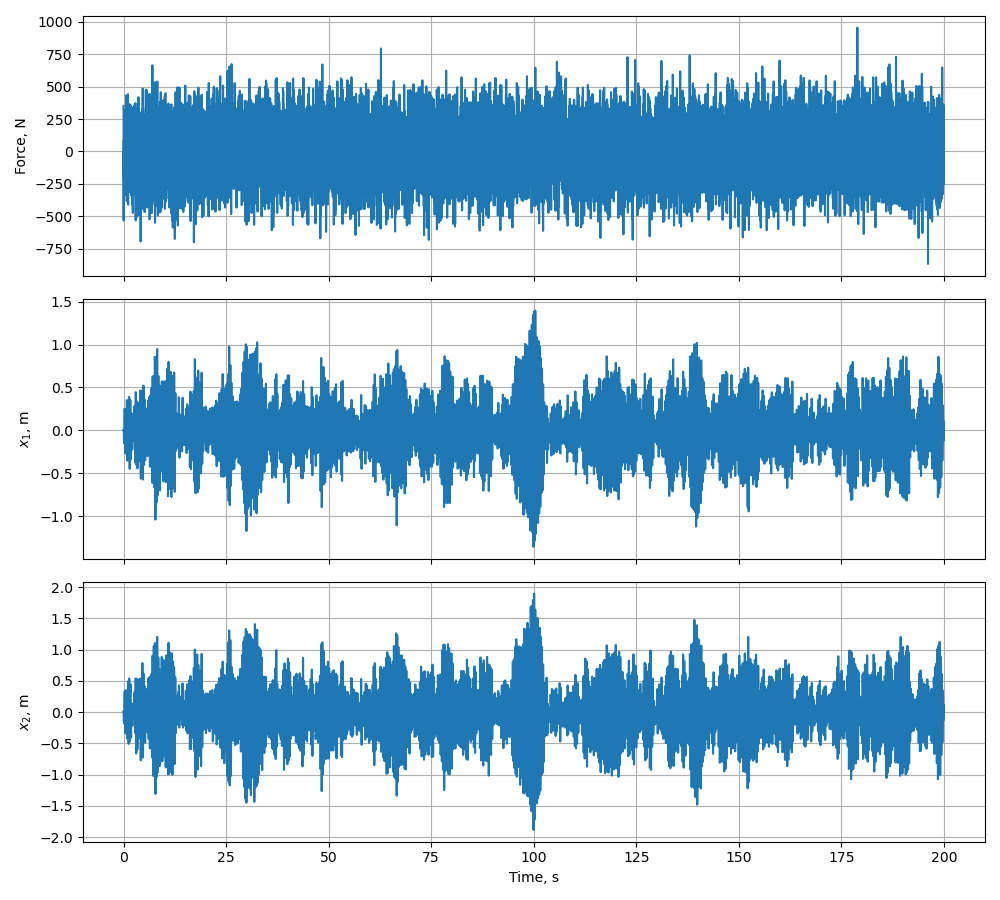

In [3]:
from scipy.interpolate import interp1d  # import interp1d function for interpolation
from scipy.integrate import odeint  # import odeint function for solving ODEs
import matplotlib.pyplot as plt  # import matplotlib library for plotting

# Enable interactive plots
%matplotlib widget

# Create time array
t_span = 200  # [s]
f_sampling = 100  # sampling frequency [Hz]
t_vector = np.arange(0, t_span, 1 / f_sampling)  # time vector [s]

# Generate random force signal
np.random.seed(11)  # set random seed for reproducibility
force_rms = 200  # RMS of the force signal [N]
random_signal = np.random.normal(
    size=len(t_vector)
)  # random signal with normal distribution centered at 0
random_force_signal = random_signal * (
    force_rms / np.sqrt(np.mean(random_signal**2))
)  # scale random signal to desired RMS [N]

# Create interpolated force function
random_force_function = interp1d(
    t_vector, random_force_signal, bounds_error=False, fill_value=0
)

# Solve ODE
initial_state = [0, 0, 0, 0]  # zero-displacement and zero-velocity initial conditions
solution = odeint(
    two_dof_mass_spring_damper, initial_state, t_vector, args=(random_force_function,)
)

# Extract displacements at the two degrees of freedom
displacements = solution[:, :2].T

# Create figure with three subplots
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 9))

# Plot force
random_force_signal = random_force_function(t_vector)
axes[0].plot(t_vector, random_force_signal)
axes[0].set_ylabel("Force, N")
axes[0].grid(True)

# Plot displacement
axes[1].plot(t_vector, displacements[0])
axes[1].set_ylabel("$x_1$, m")
axes[1].grid(True)

# Plot velocity
axes[2].plot(t_vector, displacements[1])
axes[2].set_ylabel("$x_2$, m")
axes[2].grid(True)
axes[2].set_xlabel("Time, s")

# Set layout and show plot
plt.tight_layout()
plt.show()

In [4]:
# Calculate natural frequencies by solving eigenvalue problem (K - omega^2 M) * a = 0
eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(M) @ K)
natural_frequencies = np.sqrt(eigenvalues)

# Mass normalize the eigenvectors
mass_normalized_modes = np.zeros_like(eigenvectors)
for i in range(N_DOFS):
    # Extract the i-th mode shape
    mode = np.atleast_2d(eigenvectors[:, i])

    # Calculate the modal mass (should be 1 after normalization)
    modal_mass = mode @ M @ mode.T

    # Calculate the scaling factor
    scaling_factor = 1 / np.sqrt(modal_mass)

    # Scale the mode shape
    mass_normalized_modes[:, i] = mode[0] * scaling_factor

# Find modal damping ratios
damping_ratios = (
    1
    / (2 * natural_frequencies)
    @ (mass_normalized_modes.T @ C @ mass_normalized_modes)
)

# Print results
print("Natural frequencies (rad/s):", natural_frequencies)
print("Modal damping ratios:", damping_ratios)
print("Mode shapes (mass normalized):")
print(mass_normalized_modes)

# Verify normalization (should give identity matrix)
print("Mass orthogonality check - Phi^\intercal M Phi:")
print(mass_normalized_modes.T @ M @ mass_normalized_modes)

Natural frequencies (rad/s): [61.71015287 22.91703223]
Modal damping ratios: [0.03085508 0.01145852]
Mode shapes (mass normalized):
[[ 0.30297616  0.27362769]
 [-0.33512412  0.37106849]]
Mass orthogonality check - Phi^\intercal M Phi:
[[1.00000000e+00 1.11022302e-16]
 [1.11022302e-16 1.00000000e+00]]


<>:34: SyntaxWarning: invalid escape sequence '\i'
<>:34: SyntaxWarning: invalid escape sequence '\i'
C:\Users\qa21944\AppData\Local\Temp\ipykernel_26096\1599708943.py:34: SyntaxWarning: invalid escape sequence '\i'
  print("Mass orthogonality check - Phi^\intercal M Phi:")


### Data Processing <a name="data-processing"></a>

In [5]:
from scipy import signal


def calculate_h1_frf(
    input_signal, output_signal_array, fs, window="hann", nperseg=None, noverlap=None
):
    """
    Calculate the Frequency Response Function (FRF) using SciPy's implementation of Welch's method.

    This function computes the H1 estimator: H1(f) = Gxy(f)/Gxx(f), where:
    - Gxy(f) is the cross-spectral density between input and output
    - Gxx(f) is the power spectral density of the input

    Parameters:
    -----------
    input_signal : array_like
        Input force signal
    output_signal_array : ndarray
        Array of output displacement signals with shape (n_outputs, n_samples)
    fs : float
        Sampling frequency of the signals
    window : str or tuple or array_like
        Window specification for the spectral estimation (default: 'hann')
    nperseg : int, optional
        Length of each segment (default: min(N, 256) where N is signal length)
    noverlap : int, optional
        Number of points to overlap between segments (default: nperseg//2)

    Returns:
    --------
    freqs : ndarray
        Array of sample frequencies
    frf : ndarray
        Array of FRFs for each output signal with shape (n_outputs, n_frequencies)
    """
    # Find number of output responses and initialize list of FRFs
    n_outputs = output_signal_array.shape[0]
    frfs = []

    # Process each output channel
    for i in range(n_outputs):
        # Calculate cross-spectral density between input and output
        # This gives us Gxy(f)
        f, Gxy = signal.csd(
            input_signal,
            output_signal_array[i],
            fs=fs,
            window=window,
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="constant",
            return_onesided=False,
        )

        # Calculate power spectral density of the input
        # This gives us Gxx(f)
        _, Gxx = signal.welch(
            input_signal,
            fs=fs,
            window=window,
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="constant",
            return_onesided=False,
        )

        # Calculate H1 estimator: H1(f) = Gxy(f)/Gxx(f)
        frf_channel = Gxy / Gxx
        frfs.append(frf_channel)

    # Return the frequencies and FRFs
    return f, np.array(frfs)

In [6]:
def plot_spectrum(frequencies, spectrum, title):
    """Plot magnitude and phase spectrum of a signal

    Parameters:
    frequencies (array): Frequency vector
    spectrum (array): Complex spectrum values
    title (str): Plot title
    """
    # Get positive frequencies only (since spectrum is symmetric for real signals)
    pos_mask = frequencies >= 0
    pos_freqs = frequencies[pos_mask]
    pos_spectrum = spectrum[pos_mask]

    # Calculate magnitude and phase
    magnitude_db = 20 * np.log10(np.abs(pos_spectrum))
    phase = np.angle(pos_spectrum, deg=True)

    # Create figure with two subplots
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Plot magnitude
    axes[0].plot(pos_freqs, magnitude_db)
    axes[0].set_ylabel("Magnitude")
    axes[0].grid(True)
    axes[0].set_title(f"{title} Magnitude Spectrum")

    # Plot phase
    axes[1].plot(pos_freqs, phase)
    axes[1].set_ylabel("Phase, deg")
    axes[1].set_xlabel("Frequency, Hz")
    axes[1].grid(True)
    axes[1].set_title(f"{title} Phase Spectrum")

    return fig, axes

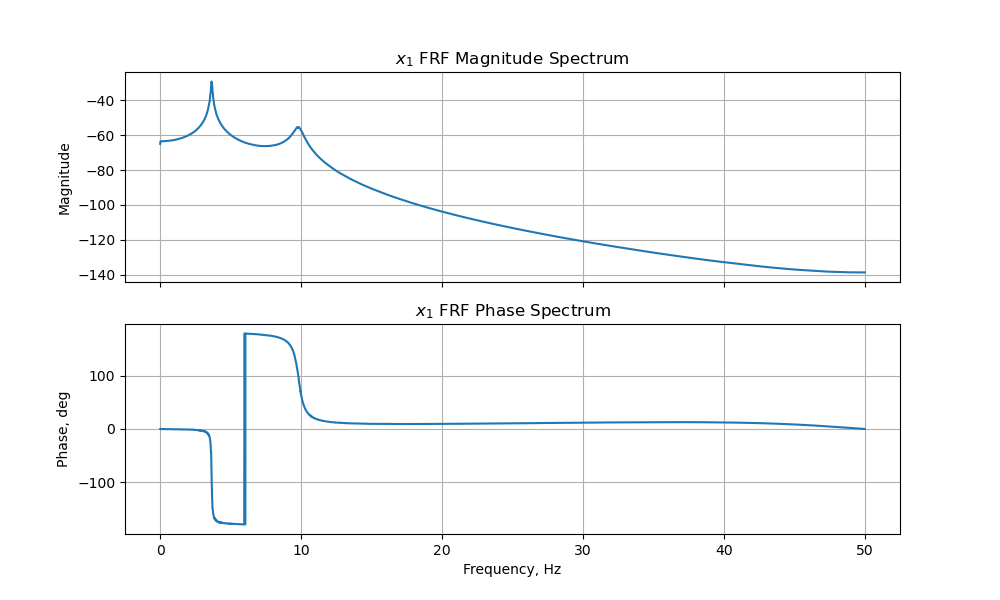

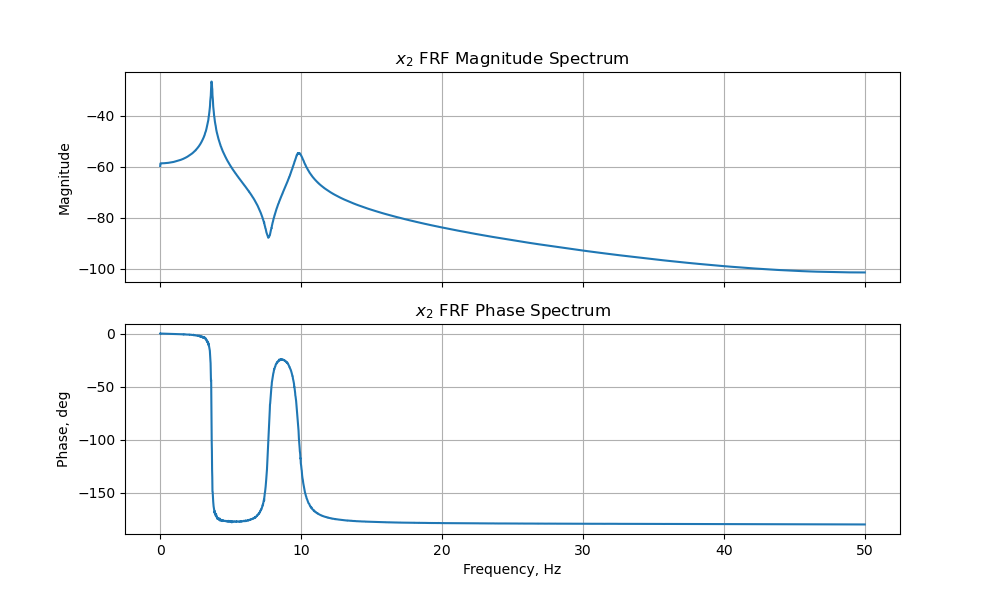

In [7]:
# Calculate improved FRF
frequencies, frfs = calculate_h1_frf(
    random_force_signal, displacements, f_sampling, nperseg=7500
)

# Plot FRF spectrum for each degree of freedom
_, _ = plot_spectrum(frequencies, frfs[0], "$x_1$ FRF")
plt.show()
_, _ = plot_spectrum(frequencies, frfs[1], "$x_2$ FRF")
plt.show()

### Parameter Estimation <a name="parameter-estimation"></a>

In [8]:
# Test 1: Only positive frequencies
positive_mask = frequencies >= 0
frequencies1 = frequencies[positive_mask]  # Only positive frequencies
weighting1 = np.sum(np.abs(frfs[:, positive_mask])**2, axis=0)
theta1, _ = generate_orthogonal_polynomials(frequencies1, order, weighting1)
print("Test 1: Positive frequencies only")
test_orthogonality(theta1, weighting1)

# Test 2: Symmetric distribution around zero
symmetric_mask = np.abs(frequencies) < f_sampling / 2
frequencies2 = frequencies[symmetric_mask]
weighting2 = np.sum(np.abs(frfs[:, symmetric_mask])**2, axis=0)
theta2, _ = generate_orthogonal_polynomials(frequencies2, order, weighting2)
print("\nTest 2: Symmetric frequencies around zero")
test_orthogonality(theta2, weighting2)

Test 1: Positive frequencies only
j=0, k=0, j+k=0: 1.0000000000+0.0000000000j (expected: non-zero)
j=1, k=0, j+k=1: 0.0000000000-0.9756416502j (expected: zero)
j=1, k=1, j+k=2: 1.0000000000+0.0000000000j (expected: non-zero)
j=2, k=0, j+k=2: 0.0000000000+0.0000000000j (expected: zero)
j=2, k=1, j+k=3: 0.0000000000-0.2030294095j (expected: zero)
j=2, k=2, j+k=4: 1.0000000000+0.0000000000j (expected: non-zero)
j=3, k=0, j+k=3: 0.0000000000-0.1261358142j (expected: zero)
j=3, k=1, j+k=4: 0.0000000000+0.0000000000j (expected: zero)
j=3, k=2, j+k=5: 0.0000000000-0.7991881696j (expected: zero)
j=3, k=3, j+k=6: 1.0000000000+0.0000000000j (expected: non-zero)
j=4, k=0, j+k=4: 0.0000000000+0.0000000000j (expected: zero)
j=4, k=1, j+k=5: 0.0000000000-0.0566734078j (expected: zero)
j=4, k=2, j+k=6: -0.0000000000+0.0000000000j (expected: zero)
j=4, k=3, j+k=7: 0.0000000000-0.5728197633j (expected: zero)
j=4, k=4, j+k=8: 1.0000000000+0.0000000000j (expected: non-zero)

Test 2: Symmetric frequencies

In [ ]:
def grfp_curve_fit(frequencies, frfs, numerator_order, denominator_order):
    """
    Implements the Global Rational Fraction Polynomial (GRFP) method for curve fitting
    multiple FRF measurements simultaneously.
    
    Parameters:
    ----------
    frequencies : ndarray
        Array of frequency points (should be a set of symmetric frequencies around zero)
    frfs : ndarray
        Array of FRF measurements with shape (n_dofs, n_frequencies)
    numerator_order : int
        Order of the numerator polynomial
    denominator_order : int
        Order of the denominator polynomial
    
    Returns:
    -------
    tuple:
        - c_coeffs: List of numerator orthogonal polynomial coefficients for each DOF
        - d_coeffs: Denominator orthogonal polynomial coefficients
        - a_coeffs: List of numerator ordinary polynomial coefficients for each DOF
        - b_coeffs: Denominator ordinary polynomial coefficients
        - Gamma_numerator: Conversion matrix for numerator polynomial
        - Gamma_denominator: Conversion matrix for denominator polynomial
    """
    # Find number of response FRFs and frequency points
    n_dofs = frfs.shape[0]
    n_freqs = frequencies.shape[0]
    
    # Create weights for polynomials
    # For numerator: uniform weighting
    numerator_weights = np.ones_like(frequencies)
    
    # For denominator: sum of squared magnitudes of all FRFs
    denominator_weights = np.sum(np.abs(frfs)**2, axis=0)
    
    # Generate numerator orthogonal polynomials
    phi, Gamma_numerator = generate_orthogonal_polynomials(
        frequencies, numerator_order, numerator_weights
    )
    
    # Generate denominator orthogonal polynomials
    theta, Gamma_denominator = generate_orthogonal_polynomials(
        frequencies, denominator_order, denominator_weights
    )

    # Setup matrices for the squared-error minimization problem
    D_T_list = []  # D_T,j matrices
    X_list = []    # X_j matrices
    H_list = []    # H_j vectors
    
    # Loop through each degree of freedom
    for j in range(n_dofs):
        # Calculate T_j matrix
        T_j = theta[:, :-1]*frfs[j][:, np.newaxis]  # Broadcasting to create T_j matrix

        # Calculate D_T,j matrix
        D_T_j = np.diag(np.sum(np.abs(T_j)**2, axis=0))  # Diagonal matrix of sum of squares along frequency points
        D_T_list.append(D_T_j)

        # Calculate X_j matrix
        X_j = -np.real(phi.conj().T @ T_j)
        X_list.append(X_j)

        # Calculate W_j vector
        W_j = frfs[j] * theta[:, -1]

        # Calculate H_j vector
        H_j = np.real(phi.conj().T @ W_j)
        H_list.append(H_j)
    
    # Calculate left and right-hand sides of the linear system for the denominator coefficients
    LHS = np.sum([D_Tj for D_Tj in D_T_list], axis=0) - np.sum([X_j.T @ X_j for X_j in X_list], axis=0)
    RHS = np.sum([X_j.T @ H_j for X_j, H_j in zip(X_list, H_list)], axis=0)

    # Solve for denominator coefficients d
    D = np.linalg.solve(LHS, RHS)

    # Add the last coefficient (d_n = 1)
    d_coeffs = np.append(D, 1)

    # Convert orthogonal denominator coefficients to ordinary denominator coefficients
    b_coeffs = Gamma_denominator @ d_coeffs
    
    # Calculate numerator coefficients c_j for each DOF and convert to ordinary coefficients
    # Initialize lists for coefficients
    a_coeffs = []
    c_coeffs = []

    # Loop through each degree of freedom
    for j in range(n_dofs):
        # Find orthogonal coefficients
        C_j = H_list[j] - X_list[j] @ D
        c_coeffs.append(C_j)

        # Convert orthogonal coefficients to ordinary coefficients
        a_coeffs.append(Gamma_numerator @ C_j)
    
    # Return the coefficients and conversion matrices
    return a_coeffs, b_coeffs

In [ ]:
# Take symmetric frequenci points around zero (exclude Nyquist frequency point)
symmetric_mask = np.abs(frequencies) < f_sampling / 2
angular_frequencies = 2* np.pi * frequencies[symmetric_mask]

# Perform global curve fitting
a_coeffs, b_coeffs = grfp_curve_fit(
    angular_frequencies, frfs[:, symmetric_mask], numerator_order=2, denominator_order=4
)